# 🔬 Breast Cancer Classification — ResNet Pipeline
**Dataset:** BUSI (Breast Ultrasound Images)  
**Task:** 3-class classification → benign / malignant / normal  
**Experiments:** Full images vs ROI images (image × segmentation mask)

## 0. Install Dependencies

In [ ]:
# !pip install torch torchvision scikit-learn matplotlib seaborn

## 1. Imports & Configuration

In [1]:
import os
import cv2
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from glob import glob

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)


# ─── Config ──────────────────────────────────────────────────────────────────
class CFG:
    # Base project directory
    BASE_DIR      = r"C:\ornekler\jupyter\deep_learning\breast-cancer"

    # Classification image source directories
    # Full images: processed/classification/{benign,malignant,normal}/
    # ROI images : processed/roi/{benign,malignant,normal}/   (image * mask)
    FULL_IMG_DIR  = os.path.join(BASE_DIR, "processed", "classification")
    ROI_IMG_DIR   = os.path.join(BASE_DIR, "processed", "roi")

    # Where to save models and outputs
    SAVE_DIR      = os.path.join(BASE_DIR, "cls_outputs")

    # Class mapping
    CLASSES       = ["benign", "malignant", "normal"]
    NUM_CLASSES   = 3

    # Training
    IMAGE_SIZE    = 224
    BATCH_SIZE    = 16
    NUM_EPOCHS    = 30
    LR            = 1e-4
    WEIGHT_DECAY  = 1e-4
    VAL_SPLIT     = 0.15
    TEST_SPLIT    = 0.15
    SEED          = 42
    NUM_WORKERS   = 0           # Set 0 on Windows/Jupyter to avoid deadlock
    DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"

    # Model
    BACKBONE      = "resnet50"  # "resnet18" or "resnet50"

os.makedirs(CFG.SAVE_DIR, exist_ok=True)

torch.manual_seed(CFG.SEED)
np.random.seed(CFG.SEED)

print(f"Device  : {CFG.DEVICE}")
print(f"Backbone: {CFG.BACKBONE}")
print(f"Classes : {CFG.CLASSES}")

Device  : cuda
Backbone: resnet50
Classes : ['benign', 'malignant', 'normal']


## 2. ROI Image Generation
If ROI images do not exist yet, generate them here by multiplying ultrasound images with their predicted segmentation masks.

In [2]:
def generate_roi_images(full_img_dir, pred_mask_dir, roi_out_dir, size=224):
    """
    For each image: ROI = image * binary_mask
    Saves ROI images preserving the class subfolder structure.

    Expected pred_mask_dir naming: <stem>_pred_mask.png
    """
    for cls in CFG.CLASSES:
        cls_img_dir = os.path.join(full_img_dir, cls)
        cls_roi_dir = os.path.join(roi_out_dir,  cls)
        os.makedirs(cls_roi_dir, exist_ok=True)

        img_paths = sorted(glob(os.path.join(cls_img_dir, "*.png")))
        saved = 0

        for img_path in img_paths:
            stem      = Path(img_path).stem
            mask_name = stem + "_pred_mask.png"
            mask_path = os.path.join(pred_mask_dir, mask_name)

            if not os.path.exists(mask_path):
                # No predicted mask found — skip or use original
                continue

            img  = cv2.imread(img_path)
            img  = cv2.resize(img,  (size, size))
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, (size, size))

            # Normalize mask to [0, 1] and expand to 3 channels
            mask_norm = (mask / 255.0).astype(np.float32)
            mask_3ch  = np.stack([mask_norm] * 3, axis=-1)   # (H, W, 3)

            # Apply mask — pixels outside ROI become black
            roi = (img.astype(np.float32) * mask_3ch).astype(np.uint8)

            out_path = os.path.join(cls_roi_dir, stem + "_roi.png")
            cv2.imwrite(out_path, roi)
            saved += 1

        print(f"  [{cls}] {saved} ROI images saved")


# Run only if ROI directory doesn't already exist
pred_mask_dir = os.path.join(CFG.BASE_DIR, "predicted_masks")

if not os.path.exists(CFG.ROI_IMG_DIR):
    print("Generating ROI images...")
    os.makedirs(CFG.ROI_IMG_DIR, exist_ok=True)
    generate_roi_images(CFG.FULL_IMG_DIR, pred_mask_dir, CFG.ROI_IMG_DIR)
    print("ROI generation complete.")
else:
    print("ROI directory already exists — skipping generation.")

Generating ROI images...
  [benign] 437 ROI images saved
  [malignant] 210 ROI images saved
  [normal] 133 ROI images saved
ROI generation complete.


## 3. Dataset & Data Loading

In [3]:
class BUSIClassificationDataset(Dataset):
    """
    Flat directory structure dataset for BUSI classification.

    root/
      benign/    → class 0
      malignant/ → class 1
      normal/    → class 2
    """

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels      = labels
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = cv2.imread(self.image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)     # → PIL-compatible RGB

        if self.transform:
            img = self.transform(img)

        label = torch.tensor(self.labels[idx], dtype=torch.long)
        return img, label


def load_paths_and_labels(root_dir, classes):
    """Collect all image paths and integer labels from a class-subfolder layout."""
    paths, labels = [], []
    for label_idx, cls in enumerate(classes):
        cls_dir = os.path.join(root_dir, cls)
        imgs    = sorted(glob(os.path.join(cls_dir, "*.png")))
        paths.extend(imgs)
        labels.extend([label_idx] * len(imgs))
        print(f"  {cls:12s}: {len(imgs)} images")
    return paths, labels


def build_splits(paths, labels, val_split, test_split, seed):
    """Stratified train / val / test split."""
    # First split off test
    tr_paths, te_paths, tr_labels, te_labels = train_test_split(
        paths, labels, test_size=test_split,
        stratify=labels, random_state=seed
    )
    # Then split train into train / val
    val_ratio = val_split / (1.0 - test_split)
    tr_paths, va_paths, tr_labels, va_labels = train_test_split(
        tr_paths, tr_labels, test_size=val_ratio,
        stratify=tr_labels, random_state=seed
    )
    return (tr_paths, tr_labels), (va_paths, va_labels), (te_paths, te_labels)


# ─── Transforms ───────────────────────────────────────────────────────────────
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

val_test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((CFG.IMAGE_SIZE, CFG.IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])


def build_dataloaders(root_dir, classes, batch_size, num_workers):
    """End-to-end: paths → splits → datasets → dataloaders."""
    print(f"\nLoading from: {root_dir}")
    paths, labels = load_paths_and_labels(root_dir, classes)

    (tr_p, tr_l), (va_p, va_l), (te_p, te_l) = build_splits(
        paths, labels, CFG.VAL_SPLIT, CFG.TEST_SPLIT, CFG.SEED
    )
    print(f"  Train: {len(tr_p)}  Val: {len(va_p)}  Test: {len(te_p)}")

    train_ds = BUSIClassificationDataset(tr_p, tr_l, train_transform)
    val_ds   = BUSIClassificationDataset(va_p, va_l, val_test_transform)
    test_ds  = BUSIClassificationDataset(te_p, te_l, val_test_transform)

    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                          num_workers=num_workers)
    val_dl   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                          num_workers=num_workers)
    test_dl  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                          num_workers=num_workers)

    return train_dl, val_dl, test_dl, te_p, te_l


print("=" * 45)
print("FULL IMAGE DATASET")
full_train_dl, full_val_dl, full_test_dl, full_te_paths, full_te_labels = \
    build_dataloaders(CFG.FULL_IMG_DIR, CFG.CLASSES, CFG.BATCH_SIZE, CFG.NUM_WORKERS)

print("=" * 45)
print("ROI IMAGE DATASET")
roi_train_dl, roi_val_dl, roi_test_dl, roi_te_paths, roi_te_labels = \
    build_dataloaders(CFG.ROI_IMG_DIR, CFG.CLASSES, CFG.BATCH_SIZE, CFG.NUM_WORKERS)

FULL IMAGE DATASET

Loading from: C:\ornekler\jupyter\deep_learning\breast-cancer\processed\classification
  benign      : 437 images
  malignant   : 210 images
  normal      : 133 images
  Train: 545  Val: 118  Test: 117
ROI IMAGE DATASET

Loading from: C:\ornekler\jupyter\deep_learning\breast-cancer\processed\roi
  benign      : 437 images
  malignant   : 210 images
  normal      : 133 images
  Train: 545  Val: 118  Test: 117


## 4. Model — Pretrained ResNet

In [4]:
def build_resnet(backbone="resnet50", num_classes=3, freeze_encoder=False):
    """
    Load a pretrained ResNet and replace its final FC layer
    with a new head for `num_classes` outputs.

    freeze_encoder=True: only train the new head (fast, good for small datasets).
    freeze_encoder=False: fine-tune all layers (more powerful).
    """
    if backbone == "resnet18":
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        in_features = 512
    elif backbone == "resnet50":
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        in_features = 2048
    else:
        raise ValueError(f"Unsupported backbone: {backbone}")

    if freeze_encoder:
        for param in model.parameters():
            param.requires_grad = False

    # Replace final fully-connected layer
    model.fc = nn.Sequential(
        nn.Dropout(p=0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(256, num_classes)
    )

    return model.to(CFG.DEVICE)


# Quick model summary
model_test = build_resnet(CFG.BACKBONE, CFG.NUM_CLASSES)
total      = sum(p.numel() for p in model_test.parameters())
trainable  = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
print(f"Backbone        : {CFG.BACKBONE}")
print(f"Total params    : {total:,}")
print(f"Trainable params: {trainable:,}")
del model_test

Backbone        : resnet50
Total params    : 24,033,347
Trainable params: 24,033,347


## 5. Training & Validation Loop

In [5]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)              # (B, num_classes) — raw logits
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs     = model(images)
        loss        = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        preds       = outputs.argmax(dim=1)
        correct    += (preds == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


def train_model(train_dl, val_dl, save_name, num_epochs=CFG.NUM_EPOCHS):
    """
    Full training loop. Returns the best model state dict and history dict.
    Saves the best checkpoint based on validation accuracy.
    """
    model     = build_resnet(CFG.BACKBONE, CFG.NUM_CLASSES)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=CFG.LR,
                           weight_decay=CFG.WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    best_acc        = 0.0
    best_state      = None
    save_path       = os.path.join(CFG.SAVE_DIR, f"{save_name}.pth")

    history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  []}

    print(f"\n{'─'*65}")
    print(f"  Training: {save_name}")
    print(f"{'─'*65}")
    print(f"{'Epoch':>6} | {'T-Loss':>8} | {'T-Acc':>7} | {'V-Loss':>8} | {'V-Acc':>7} | {'':>8}")
    print(f"{'─'*65}")

    for epoch in range(1, num_epochs + 1):
        t_loss, t_acc = train_one_epoch(model, train_dl, criterion, optimizer, CFG.DEVICE)
        v_loss, v_acc = validate(model, val_dl, criterion, CFG.DEVICE)
        scheduler.step()

        history["train_loss"].append(t_loss); history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc);   history["val_acc"].append(v_acc)

        flag = ""
        if v_acc > best_acc:
            best_acc   = v_acc
            best_state = copy.deepcopy(model.state_dict())
            torch.save(best_state, save_path)
            flag = "✅ best"

        print(f"{epoch:>6} | {t_loss:>8.4f} | {t_acc:>6.2%} | "
              f"{v_loss:>8.4f} | {v_acc:>6.2%} | {flag}")

    print(f"\nBest Val Acc: {best_acc:.4%}  →  saved: {save_path}")

    # Load best weights back into model
    model.load_state_dict(best_state)
    return model, history

## 6. Experiment A — Train on Full Images

In [6]:
full_model, full_history = train_model(
    full_train_dl, full_val_dl,
    save_name="resnet_full_images"
)


─────────────────────────────────────────────────────────────────
  Training: resnet_full_images
─────────────────────────────────────────────────────────────────
 Epoch |   T-Loss |   T-Acc |   V-Loss |   V-Acc |         
─────────────────────────────────────────────────────────────────
     1 |   0.9767 | 55.41% |   0.9027 | 55.93% | ✅ best
     2 |   0.8245 | 55.96% |   0.7275 | 55.93% | 
     3 |   0.7252 | 59.45% |   0.6358 | 71.19% | ✅ best
     4 |   0.6374 | 71.38% |   0.5549 | 73.73% | ✅ best
     5 |   0.5373 | 78.53% |   0.4748 | 83.05% | ✅ best
     6 |   0.4263 | 84.77% |   0.4254 | 84.75% | ✅ best
     7 |   0.4359 | 82.39% |   0.3586 | 86.44% | ✅ best
     8 |   0.3532 | 88.44% |   0.4957 | 87.29% | ✅ best
     9 |   0.3600 | 86.24% |   0.3777 | 85.59% | 
    10 |   0.2366 | 90.46% |   0.5750 | 83.05% | 
    11 |   0.2842 | 90.09% |   0.3795 | 88.14% | ✅ best
    12 |   0.2115 | 91.19% |   0.3854 | 87.29% | 
    13 |   0.2092 | 91.74% |   0.3928 | 88.98% | ✅ best
    14

## 7. Experiment B — Train on ROI Images

In [7]:
roi_model, roi_history = train_model(
    roi_train_dl, roi_val_dl,
    save_name="resnet_roi_images"
)


─────────────────────────────────────────────────────────────────
  Training: resnet_roi_images
─────────────────────────────────────────────────────────────────
 Epoch |   T-Loss |   T-Acc |   V-Loss |   V-Acc |         
─────────────────────────────────────────────────────────────────
     1 |   0.9328 | 50.64% |   0.8256 | 56.78% | ✅ best
     2 |   0.6869 | 74.68% |   0.6838 | 73.73% | ✅ best
     3 |   0.5747 | 78.35% |   0.5525 | 83.90% | ✅ best
     4 |   0.4931 | 81.83% |   0.5748 | 73.73% | 
     5 |   0.4735 | 83.67% |   0.5450 | 74.58% | 
     6 |   0.4481 | 82.57% |   0.4483 | 84.75% | ✅ best
     7 |   0.4358 | 82.75% |   0.5652 | 84.75% | 
     8 |   0.3964 | 84.22% |   0.5541 | 79.66% | 
     9 |   0.4239 | 83.30% |   0.5390 | 80.51% | 
    10 |   0.4166 | 84.04% |   0.4734 | 82.20% | 
    11 |   0.3684 | 85.50% |   0.4624 | 83.90% | 
    12 |   0.3587 | 87.16% |   0.4762 | 83.90% | 
    13 |   0.3210 | 88.07% |   0.4164 | 86.44% | ✅ best
    14 |   0.3078 | 88.81% |   

## 8. Training Curves Comparison

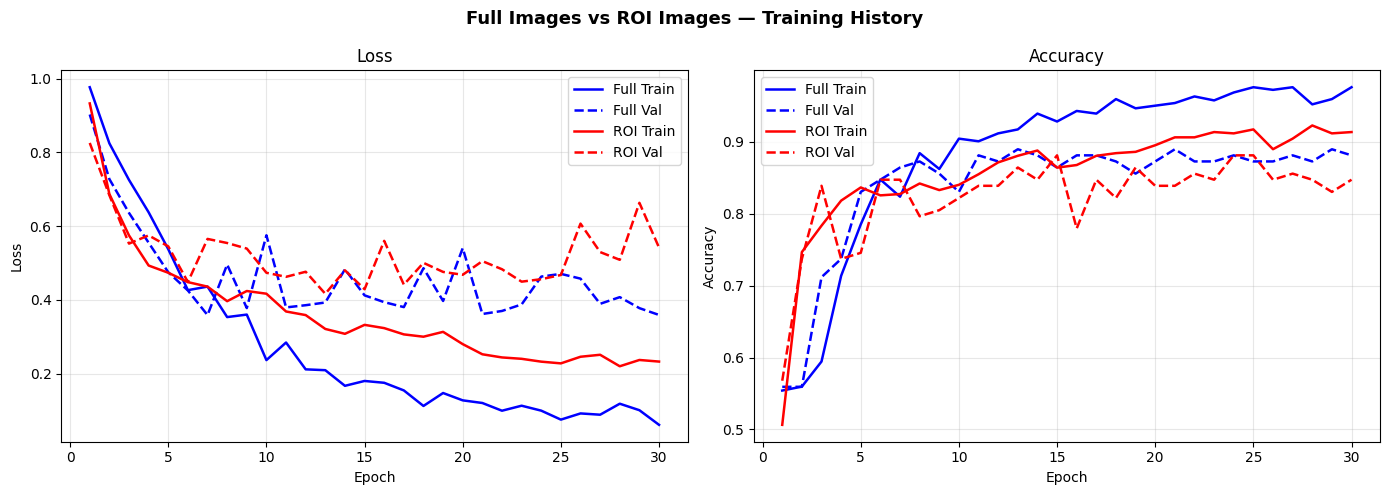

In [8]:
def plot_history_comparison(hist_full, hist_roi, save_path):
    epochs = range(1, len(hist_full["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Full Images vs ROI Images — Training History",
                 fontsize=13, fontweight="bold")

    for ax, metric, ylabel in zip(
        axes,
        [("train_loss", "val_loss"), ("train_acc", "val_acc")],
        ["Loss", "Accuracy"]
    ):
        train_key, val_key = metric
        ax.plot(epochs, hist_full[train_key], "b-",  label="Full Train", linewidth=1.8)
        ax.plot(epochs, hist_full[val_key],   "b--", label="Full Val",   linewidth=1.8)
        ax.plot(epochs, hist_roi[train_key],  "r-",  label="ROI Train",  linewidth=1.8)
        ax.plot(epochs, hist_roi[val_key],    "r--", label="ROI Val",    linewidth=1.8)
        ax.set_xlabel("Epoch"); ax.set_ylabel(ylabel)
        ax.set_title(ylabel); ax.legend(); ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(save_path, dpi=120)
    plt.show()


plot_history_comparison(
    full_history, roi_history,
    save_path=os.path.join(CFG.SAVE_DIR, "training_curves_comparison.png")
)

## 9. Evaluation on Test Set

In [9]:
@torch.no_grad()
def get_predictions(model, loader, device):
    """Run inference on a DataLoader; return all true labels and predicted labels."""
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    for images, labels in loader:
        images  = images.to(device)
        outputs = model(images)                          # (B, C)
        probs   = torch.softmax(outputs, dim=1).cpu()    # probabilities
        preds   = outputs.argmax(dim=1).cpu()

        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)


def evaluate_model(model, test_dl, experiment_name):
    """Print classification report and return metrics dict."""
    y_true, y_pred, y_prob = get_predictions(model, test_dl, CFG.DEVICE)

    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="weighted")

    print(f"\n{'='*50}")
    print(f"  {experiment_name} — Test Results")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.4%}")
    print(f"  F1 (wtd) : {f1:.4f}")
    print()
    print(classification_report(y_true, y_pred,
                                 target_names=CFG.CLASSES, digits=4))

    return {"y_true": y_true, "y_pred": y_pred,
            "y_prob": y_prob, "acc": acc, "f1": f1}


full_results = evaluate_model(full_model, full_test_dl, "Full Images")
roi_results  = evaluate_model(roi_model,  roi_test_dl,  "ROI Images")


  Full Images — Test Results
  Accuracy : 95.7265%
  F1 (wtd) : 0.9577

              precision    recall  f1-score   support

      benign     0.9692    0.9545    0.9618        66
   malignant     1.0000    0.9355    0.9667        31
      normal     0.8696    1.0000    0.9302        20

    accuracy                         0.9573       117
   macro avg     0.9463    0.9633    0.9529       117
weighted avg     0.9603    0.9573    0.9577       117


  ROI Images — Test Results
  Accuracy : 85.4701%
  F1 (wtd) : 0.8540

              precision    recall  f1-score   support

      benign     0.8824    0.9091    0.8955        66
   malignant     0.7667    0.7419    0.7541        31
      normal     0.8947    0.8500    0.8718        20

    accuracy                         0.8547       117
   macro avg     0.8479    0.8337    0.8405       117
weighted avg     0.8538    0.8547    0.8540       117



## 10. Confusion Matrices

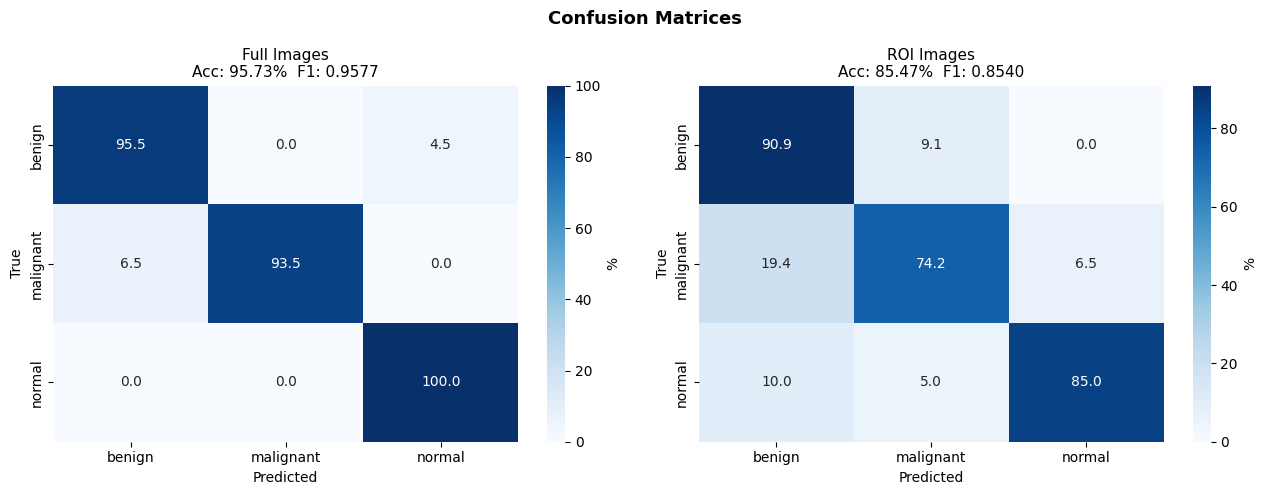

In [10]:
def plot_confusion_matrices(full_res, roi_res, classes, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle("Confusion Matrices", fontsize=13, fontweight="bold")

    for ax, res, title in zip(
        axes,
        [full_res, roi_res],
        ["Full Images", "ROI Images"]
    ):
        cm = confusion_matrix(res["y_true"], res["y_pred"])
        # Normalize to percentages per row
        cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

        sns.heatmap(
            cm_pct, annot=True, fmt=".1f", cmap="Blues",
            xticklabels=classes, yticklabels=classes,
            ax=ax, cbar_kws={"label": "%"}
        )
        ax.set_title(f"{title}\nAcc: {res['acc']:.2%}  F1: {res['f1']:.4f}",
                     fontsize=11)
        ax.set_xlabel("Predicted"); ax.set_ylabel("True")

    plt.tight_layout()
    plt.savefig(save_path, dpi=120)
    plt.show()


plot_confusion_matrices(
    full_results, roi_results, CFG.CLASSES,
    save_path=os.path.join(CFG.SAVE_DIR, "confusion_matrices.png")
)

## 11. Side-by-Side Results Comparison

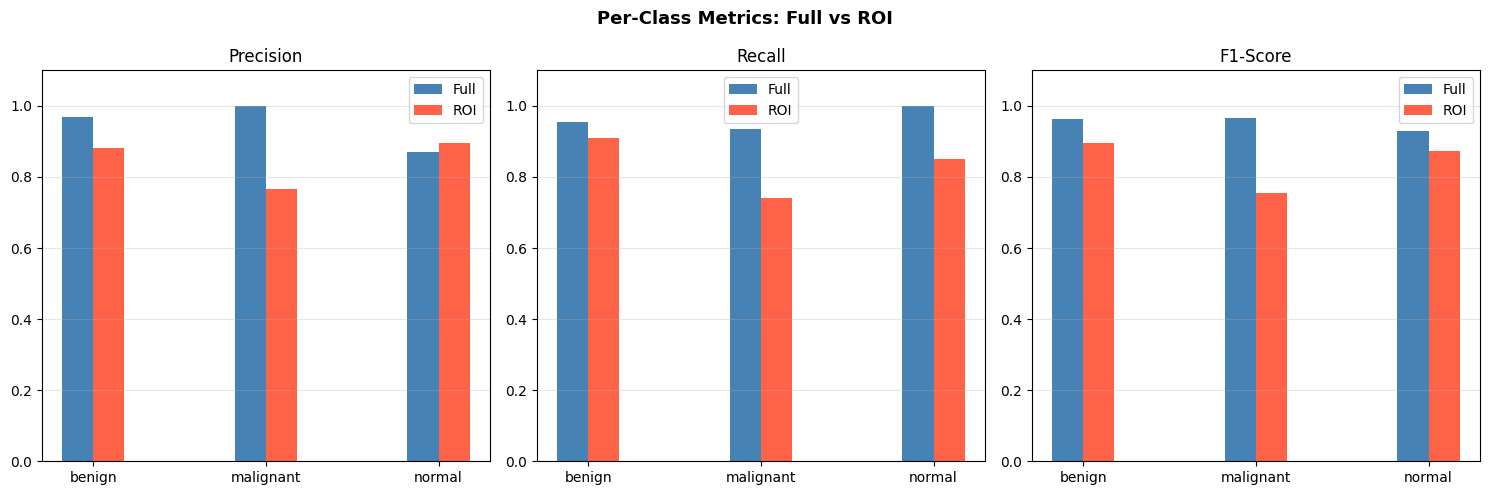


Metric                  Full Images     ROI Images
--------------------------------------------------
Accuracy                   95.7265%       85.4701%
F1 (weighted)                0.9577         0.8540


In [11]:
def plot_metric_comparison(full_res, roi_res, classes):
    from sklearn.metrics import precision_recall_fscore_support

    metrics_full = precision_recall_fscore_support(
        full_res["y_true"], full_res["y_pred"], average=None, labels=[0,1,2])
    metrics_roi  = precision_recall_fscore_support(
        roi_res["y_true"],  roi_res["y_pred"],  average=None, labels=[0,1,2])

    x = np.arange(len(classes))
    w = 0.18

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle("Per-Class Metrics: Full vs ROI", fontsize=13, fontweight="bold")

    for ax, metric_idx, label in zip(
        axes, [0, 1, 2], ["Precision", "Recall", "F1-Score"]
    ):
        ax.bar(x - w/2, metrics_full[metric_idx], width=w, label="Full", color="steelblue")
        ax.bar(x + w/2, metrics_roi[metric_idx],  width=w, label="ROI",  color="tomato")
        ax.set_xticks(x); ax.set_xticklabels(classes)
        ax.set_ylim(0, 1.1); ax.set_title(label)
        ax.legend(); ax.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(CFG.SAVE_DIR, "metric_comparison.png"), dpi=120)
    plt.show()


plot_metric_comparison(full_results, roi_results, CFG.CLASSES)

# Summary table
print(f"\n{'Metric':<20} {'Full Images':>14} {'ROI Images':>14}")
print("-" * 50)
print(f"{'Accuracy':<20} {full_results['acc']:>14.4%} {roi_results['acc']:>14.4%}")
print(f"{'F1 (weighted)':<20} {full_results['f1']:>14.4f} {roi_results['f1']:>14.4f}")

## 12. Prediction Visualization — Correct & Misclassified

Full Image Model Predictions


C:\Users\dellg\AppData\Local\Temp\ipykernel_10584\3604653320.py:65: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.tight_layout()
C:\Users\dellg\AppData\Local\Temp\ipykernel_10584\3604653320.py:65: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.tight_layout()
C:\Users\dellg\AppData\Local\Temp\ipykernel_10584\3604653320.py:67: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  plt.savefig(save_path, dpi=120)
C:\Users\dellg\AppData\Local\Temp\ipykernel_10584\3604653320.py:67: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  plt.savefig(save_path, dpi=120)
C:\Users\dellg\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\dellg\AppData\Roaming\Python\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarnin

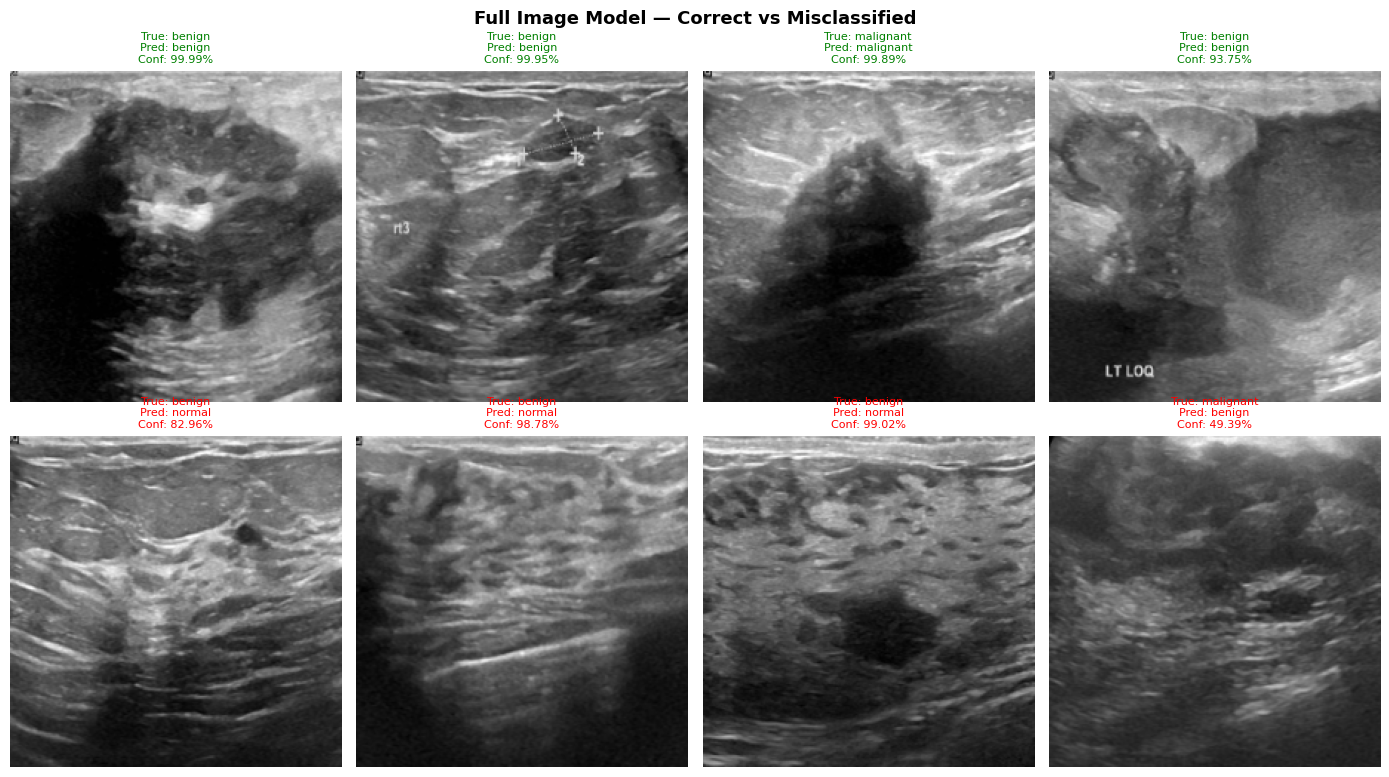

ROI Model Predictions


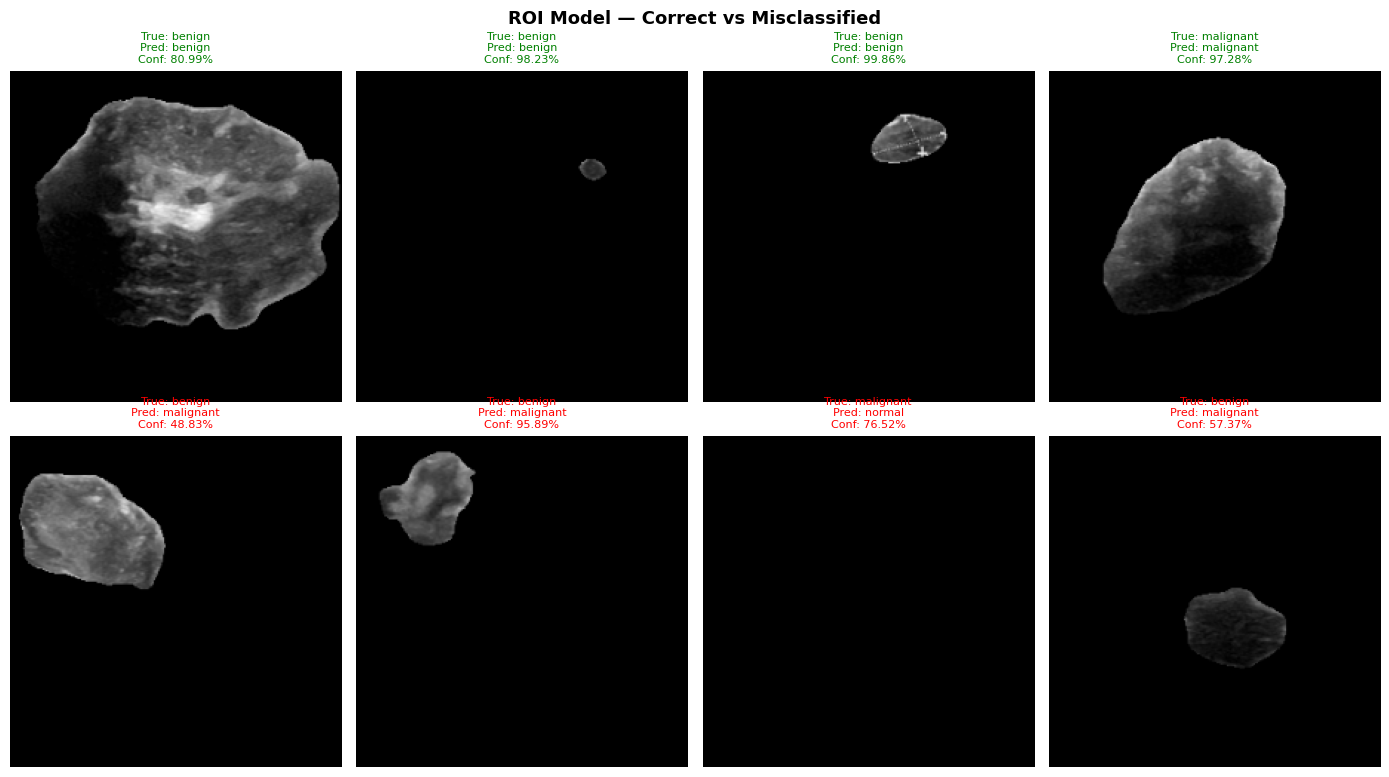

In [12]:
def denormalize(tensor):
    """Reverse ImageNet normalization for display."""
    t = tensor.clone().permute(1, 2, 0).numpy()
    t = t * np.array(STD) + np.array(MEAN)
    return np.clip(t, 0, 1)


def show_predictions(model, image_paths, true_labels, classes, device,
                     n_correct=4, n_wrong=4, title="Predictions", save_path=None):
    """
    Display a grid of:
      - Top row: correctly classified examples
      - Bottom row: misclassified examples
    """
    model.eval()

    correct_samples, wrong_samples = [], []

    for img_path, true_lbl in zip(image_paths, true_labels):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        tensor = val_test_transform(img).unsqueeze(0).to(device)

        with torch.no_grad():
            out  = model(tensor)
            prob = torch.softmax(out, dim=1).cpu().numpy()[0]
            pred = np.argmax(prob)

        entry = (img_path, true_lbl, pred, prob)
        if pred == true_lbl and len(correct_samples) < n_correct:
            correct_samples.append(entry)
        elif pred != true_lbl and len(wrong_samples) < n_wrong:
            wrong_samples.append(entry)

        if len(correct_samples) == n_correct and len(wrong_samples) == n_wrong:
            break

    n_rows = 2
    n_cols = max(n_correct, n_wrong)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3.5, 8))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    row_data  = [correct_samples, wrong_samples]
    row_titles= ["✅ Correct", "❌ Misclassified"]

    for r, (samples, row_title) in enumerate(zip(row_data, row_titles)):
        axes[r][0].set_ylabel(row_title, fontsize=11, rotation=90, labelpad=10)
        for c in range(n_cols):
            ax = axes[r][c]
            if c < len(samples):
                img_path, true_lbl, pred, prob = samples[c]
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = cv2.resize(img, (CFG.IMAGE_SIZE, CFG.IMAGE_SIZE))

                ax.imshow(img)
                color = "green" if pred == true_lbl else "red"
                ax.set_title(
                    f"True: {classes[true_lbl]}\nPred: {classes[pred]}\n"
                    f"Conf: {prob[pred]:.2%}",
                    fontsize=8, color=color
                )
            ax.axis("off")

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120)
    plt.show()


print("Full Image Model Predictions")
show_predictions(
    full_model, full_te_paths, full_te_labels, CFG.CLASSES, CFG.DEVICE,
    title="Full Image Model — Correct vs Misclassified",
    save_path=os.path.join(CFG.SAVE_DIR, "preds_full.png")
)

print("ROI Model Predictions")
show_predictions(
    roi_model, roi_te_paths, roi_te_labels, CFG.CLASSES, CFG.DEVICE,
    title="ROI Model — Correct vs Misclassified",
    save_path=os.path.join(CFG.SAVE_DIR, "preds_roi.png")
)

## 13. Final Summary

In [13]:
winner = "ROI Images" if roi_results["f1"] > full_results["f1"] else "Full Images"

print("\n" + "=" * 55)
print("  EXPERIMENT SUMMARY")
print("=" * 55)
print(f"  {'Experiment':<25} {'Accuracy':>10} {'F1 (wtd)':>10}")
print("-" * 55)
print(f"  {'Full Images':<25} {full_results['acc']:>10.4%} {full_results['f1']:>10.4f}")
print(f"  {'ROI Images':<25} {roi_results['acc']:>10.4%} {roi_results['f1']:>10.4f}")
print("=" * 55)
print(f"  Winner: {winner}")
print("=" * 55)
print(f"\n  Saved outputs → {CFG.SAVE_DIR}")


  EXPERIMENT SUMMARY
  Experiment                  Accuracy   F1 (wtd)
-------------------------------------------------------
  Full Images                 95.7265%     0.9577
  ROI Images                  85.4701%     0.8540
  Winner: Full Images

  Saved outputs → C:\ornekler\jupyter\deep_learning\breast-cancer\cls_outputs
